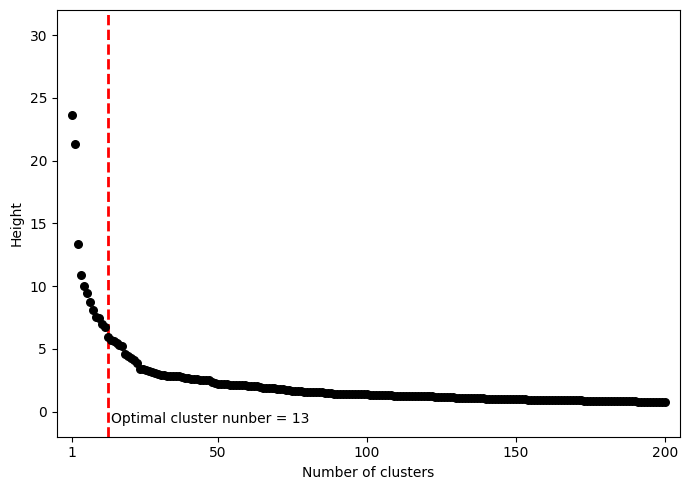

[INFO] Optimal number of clusters (L-method RMSE): 13
[INFO] Grid–cluster membership saved
[INFO] Figure saved: output\scenario=all\cell=40km\threshold=5\cluster_number\all_40km_5_height_vs_K_20260110.tif


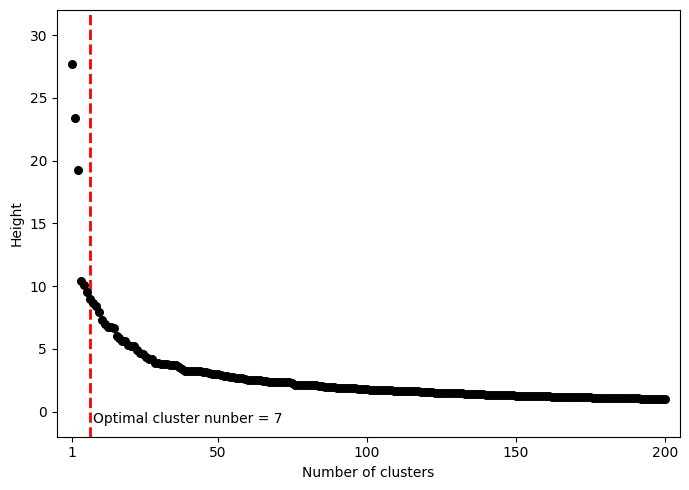

[INFO] Optimal number of clusters (L-method RMSE): 7
[INFO] Grid–cluster membership saved
[INFO] Figure saved: output\scenario=all\cell=40km\threshold=1\cluster_number\all_40km_1_height_vs_K_20260110.tif


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from pathlib import Path
from datetime import datetime

def plot_normalized_node_height_vs_K(
    scenario,
    cell_size,
    threshold,
    method='ward'):

    # ======================================================
    # 1. Load beta diversity matrix
    # ======================================================
    file_path = Path(
        f'output/scenario={scenario}/cell={cell_size//1000}km/threshold={threshold}/'
        f'{scenario}_{cell_size//1000}km_{threshold}_beta_diversity_matrix.xlsx'
    )

    dissimilarity_matrix = pd.read_excel(file_path, index_col=0).astype(float)
    condensed_dist = squareform(dissimilarity_matrix.values)

    # ======================================================
    # 2. Hierarchical clustering
    # ======================================================
    Z = linkage(condensed_dist, method=method)
    n_samples = dissimilarity_matrix.shape[0]

    max_height = Z[:, 2].max()

    # ======================================================
    # 3. Height vs cluster number
    # ======================================================
    max_K = min(200, n_samples - 1)

    cluster_nums = []
    node_heights_norm = []

    for K in range(1, max_K + 1):
        idx = n_samples - K - 1
        height = Z[idx, 2]
        # height_norm = height / max_height

        cluster_nums.append(K)
        node_heights_norm.append(height)

    df = pd.DataFrame({
        'n_clusters': cluster_nums,
        'normalized_node_height': node_heights_norm
    })

    # ======================================================
    # 4. Drop from n → n+1 (K=max has no drop by definition)
    # ======================================================
    df['drop'] = df['normalized_node_height'].diff(-1)

    # ======================================================
    # 5. L-method: RMSE calculation
    # ======================================================
    rmse_list = []
    candidate_K = range(2, max_K - 1)

    x = df['n_clusters'].values
    y = df['normalized_node_height'].values

    for K in candidate_K:
        # left segment
        xL, yL = x[:K], y[:K]
        coef_L = np.polyfit(xL, yL, 1)
        yL_hat = np.polyval(coef_L, xL)
        rmse_L = np.sqrt(np.mean((yL - yL_hat) ** 2))

        # right segment
        xR, yR = x[K-1:], y[K-1:]
        coef_R = np.polyfit(xR, yR, 1)
        yR_hat = np.polyval(coef_R, xR)
        rmse_R = np.sqrt(np.mean((yR - yR_hat) ** 2))

        # weighted RMSE
        rmse = np.sqrt(
            (len(yL) * rmse_L**2 + len(yR) * rmse_R**2) /
            (len(yL) + len(yR))
        )

        rmse_list.append(rmse)

    rmse_df = pd.DataFrame({
        'n_clusters': list(candidate_K),
        'RMSE': rmse_list
    })

    optimal_K = rmse_df.loc[rmse_df['RMSE'].idxmin(), 'n_clusters']

    # ======================================================
    # 6. Assign each grid to cluster using optimal_K
    # ======================================================
    cluster_labels = fcluster(
        Z,
        t=optimal_K,
        criterion='maxclust'
    )

    cluster_df = pd.DataFrame({
        'grid_index': dissimilarity_matrix.index,
        'cluster': cluster_labels
    }).set_index('grid_index')

    # ======================================================
    # 7. Save outputs
    # ======================================================
    output_dir = file_path.parent / 'cluster_number'
    output_dir.mkdir(parents=True, exist_ok=True)

    df.to_excel(
        output_dir /
        f'{scenario}_{cell_size//1000}km_{threshold}_height_vs_K.xlsx',
        index=False
    )

    rmse_df.to_excel(
        output_dir /
        f'{scenario}_{cell_size//1000}km_{threshold}_Lmethod_RMSE.xlsx',
        index=False
    )

    cluster_df.to_excel(
        output_dir /
        f'{scenario}_{cell_size//1000}km_{threshold}_grid_cluster.xlsx'
    )

    # ======================================================
    # 8. Plot
    # ======================================================
    fig, ax1 = plt.subplots(figsize=(7, 5))
    colors = ['#E64B35FF', '#4DBBD5FF', '#00A087FF', '#3C5488FF', '#F39B7FFF', '#8491B4FF', '#91D1C2FF', '#dC0000FF', '#7E6148FF', '#B09C85FF']
    # main axis
    ax1.scatter(
        df['n_clusters'],
        df['normalized_node_height'],
        s=30,
        facecolor='black',
        zorder=3,
        # label='Beta diversity dissimilarity $\\beta_{sim}$'
    )

    ax1.axvline(
        optimal_K,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Optimal cluster number = {optimal_K}'
    )

    ax1.set_xlabel('Number of clusters', fontsize=10)
    ax1.set_ylabel('Height', fontsize=10)
    ax1.set_ylim(-2, 32)
    ax1.set_xlim(-4, max_K + 5)
    ax1.set_xticks([1, 50, 100, 150, 200])

    # ax1.grid(True, linestyle='--', alpha=0.4)
    # ax1.spines['top'].set_visible(False)

    # # secondary axis: drop
    # ax2 = ax1.twinx()
    # ax2.plot(
    #     df['n_clusters'][:-1],
    #     df['drop'][:-1],
    #     color='grey',
    #     marker='o',
    #     markersize=3,
    #     linewidth=1.2,
    #     label='$\\Delta\\beta_{sim} (n, n+1)$'
    # )
    # ax2.set_ylabel('$\\Delta\\beta_{sim} (n, n+1)$', fontsize=10)
    # ax2.set_ylim(-0.02, 1.02)

    # legend
    # lines1, labels1 = ax1.get_legend_handles_labels()
    # # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax1.legend(
    #     lines1, # + lines2,
    #     labels1, # + labels2,
    #     frameon=False,
    #     fontsize=9
    # )

    ax1.text(
        optimal_K + 1,                # x 位置（稍微右移）
        0,                # y 位置（图内靠上）
        f'Optimal cluster nunber = {optimal_K:d}',
        fontsize=10,
        ha='left',
        va='top'
    )

    plt.tight_layout()
    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    out_fig = (
        output_dir /
        f'{scenario}_{cell_size//1000}km_{threshold}_height_vs_K_{date_str}.tif'
    )
    plt.savefig(out_fig, dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.show()

    print('[INFO] Optimal number of clusters (L-method RMSE):', optimal_K)
    print('[INFO] Grid–cluster membership saved')
    print(f'[INFO] Figure saved: {out_fig}')


# ======================================================
# Example usage
# ======================================================
plot_normalized_node_height_vs_K(scenario='all', cell_size=40000, threshold=5)
plot_normalized_node_height_vs_K(scenario='all', cell_size=40000, threshold=1)

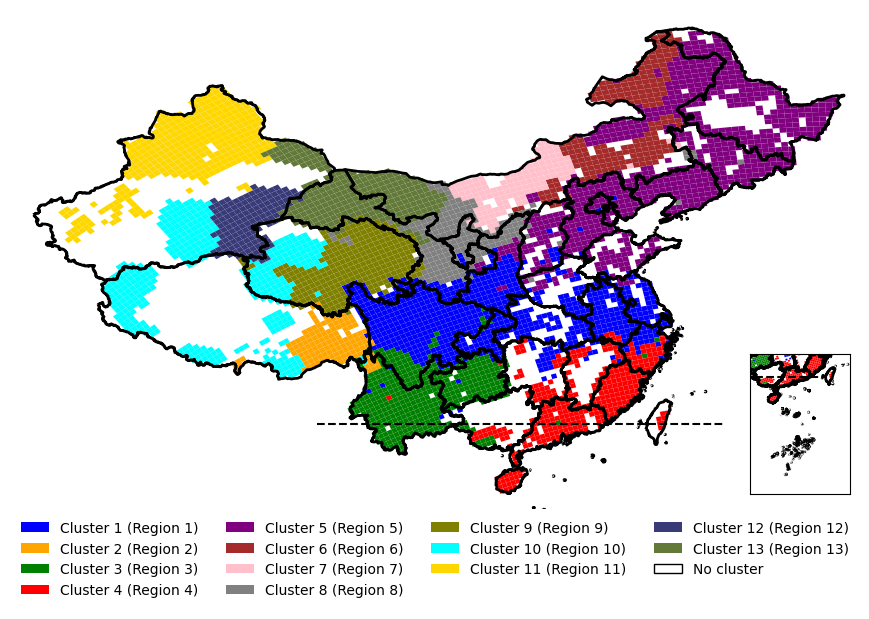

[INFO] Cluster map saved: output\scenario=all\cell=40km\threshold=5\cluster_number\all_40km_5_map_20260110.tif


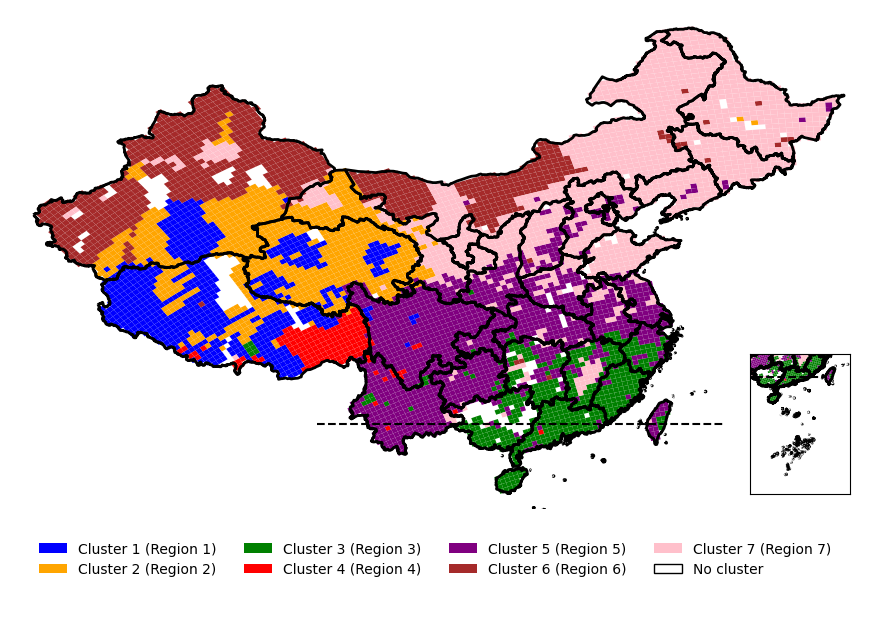

[INFO] Cluster map saved: output\scenario=all\cell=40km\threshold=1\cluster_number\all_40km_1_map_20260110.tif


In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import numpy as np
from datetime import datetime

# ======================================================
# 绘制聚类地图（主图 + 插图）函数
# ======================================================
def plot_cluster_map_and_dendrogram(scenario, cell_size, threshold):

    # ======================================================
    # 1. 构造文件路径
    # ======================================================
    cluster_file = Path(
        f'output/scenario={scenario}/cell={cell_size//1000}km/threshold={threshold}/cluster_number/{scenario}_{cell_size//1000}km_{threshold}_grid_cluster.xlsx'
    )
    grid_shp_file = Path(
        f'output/scenario={scenario}/cell={cell_size//1000}km/{scenario}_{cell_size//1000}km_grid_map.geojson'
    )

    # ======================================================
    # 2. 读取数据
    # ======================================================
    cluster_df = pd.read_excel(cluster_file)
    grid_gdf = gpd.read_file(grid_shp_file)

    # 合并聚类信息
    grid_gdf = grid_gdf.merge(cluster_df, on='grid_index', how='left')

    # ======================================================
    # 3. 设置 cluster 颜色
    # ======================================================
    # cluster_colors = {
    #     1:  {'color': '#E64B35', 'alpha': 1.0}, #1-2, same region
    #     2:  {'color': '#E64B35', 'alpha': 0.5}, #1-2, same region
    #     3:  {'color': '#4DBBD5', 'alpha': 1.0}, #3-4-5, same region
    #     4:  {'color': '#4DBBD5', 'alpha': 0.75}, #3-4-5, same region
    #     5:  {'color': '#4DBBD5', 'alpha': 0.5}, #3-4-5, same region
    #     6:  {'color': '#00A087', 'alpha': 1.0}, #6-7, same region
    #     7:  {'color': '#00A087', 'alpha': 0.5}, #6-7, same region
    #     8:  {'color': '#3C5488', 'alpha': 1.0}, #8-9-10, same region
    #     9:  {'color': '#3C5488', 'alpha': 0.75}, #8-9-10, same region
    #     10: {'color': '#3C5488', 'alpha': 0.5}, #8-9-10, same region
    #     11: {'color': 'blue', 'alpha': 0.5} #8-9-10, same region
    # }

    cluster_colors = {
        1:  {'color': 'blue', 'alpha': 1.0}, #1-2, same region
        2:  {'color': 'orange', 'alpha': 1.0}, #1-2, same region
        3:  {'color': 'green', 'alpha': 1.0}, #3-4-5, same region
        4:  {'color': 'red', 'alpha': 1.0}, #3-4-5, same region
        5:  {'color': 'purple', 'alpha': 1.0}, #3-4-5, same region
        6:  {'color': 'brown', 'alpha': 1.0}, #6-7, same region
        7:  {'color': 'pink', 'alpha': 1.0}, #6-7, same region
        8:  {'color': 'gray', 'alpha': 1.0}, #8-9-10, same region
        9:  {'color': 'olive', 'alpha': 1.0}, #8-9-10, same region
        10: {'color': 'cyan', 'alpha': 1.0}, #8-9-10, same region
        11: {'color': 'gold', 'alpha': 1.0}, #8-9-10, same region
        12: {'color': '#393B79', 'alpha': 1.0}, #8-9-10, same region
        13: {'color': '#637939', 'alpha': 1.0}, #8-9-10, same region
        14: {'color': '#8C6D31', 'alpha': 1.0}, #8-9-10, same region
        15: {'color': '#843C39', 'alpha': 1.0} #8-9-10, same region
    }
    

    grid_gdf['cluster'] = grid_gdf['cluster'].fillna(-1)
    clusters = sorted(grid_gdf.loc[grid_gdf['cluster'] != -1, 'cluster'].unique())

    # ======================================================
    # 4. 创建图和子图
    # ======================================================
    fig = plt.figure(figsize=(10, 10))
    ax_map = fig.add_axes([0, 0.5, 0.85, 0.5])
    ax_insert = fig.add_axes([0.74, 0.515, 0.1, 0.14])

    # ======================================================
    # 5. 绘制中国边界
    # ======================================================
    china = gpd.read_file('../0_map/中国_省_202509_GS(2024)0650.geojson')
    china = china[china['name'] != '境界线'].reset_index(drop=True)
    # china_dissolved = china.dissolve()
    # china_dissolved.boundary.plot(ax=ax_map, color='black', linewidth=2)
    # china_dissolved.boundary.plot(ax=ax_insert, color='black', linewidth=2)

    china.boundary.plot(ax=ax_map, color='black', linewidth=2)
    china.boundary.plot(ax=ax_insert, color='black', linewidth=2)

    # ======================================================
    # 6. 绘制 No cluster 的格子（灰色 + hatch）
    # ======================================================
    no_cluster_gdf = grid_gdf[grid_gdf['cluster'] == -1]

    for geom in no_cluster_gdf.geometry:
        if geom.geom_type == 'Polygon':
            polygons = [geom]
        elif geom.geom_type == 'MultiPolygon':
            polygons = geom.geoms
        else:
            continue

        for poly in polygons:
            ax_map.add_patch(
                mpatches.Polygon(
                    np.array(poly.exterior.coords),
                    facecolor='white',
                    linewidth=0.1
                )
            )
            ax_insert.add_patch(
                mpatches.Polygon(
                    np.array(poly.exterior.coords),
                    facecolor='white',
                    linewidth=0.1
                )
            )

    # ======================================================
    # 7. 绘制有 cluster 的格子
    # ======================================================
    clustered_gdf = grid_gdf[grid_gdf['cluster'] != -1].copy()

    for cid, style in cluster_colors.items():
        sub = clustered_gdf[clustered_gdf['cluster'] == cid]
        if sub.empty:
            continue

        sub.plot(
            color=style['color'],   # 只给颜色
            alpha=style['alpha'],   # 透明度单独给
            linewidth=0.1,
            edgecolor='none',
            ax=ax_map
        )

        sub.plot(
            color=style['color'],
            alpha=style['alpha'],
            linewidth=0.1,
            edgecolor='none',
            ax=ax_insert
        )

    # ======================================================
    # 8. 自定义图例
    # ======================================================
    cluster_to_region = {
        1: 'Region 1', 
        2: 'Region 2',
        3: 'Region 3', 
        4: 'Region 4', 
        5: 'Region 5',
        6: 'Region 6',
        7: 'Region 7',
        8: 'Region 8', 
        9: 'Region 9',
        10: 'Region 10',
        11: 'Region 11',
        12: 'Region 12',
        13: 'Region 13',
        14: 'Region 14',
        15: 'Region 15'
    }

    handles = [
        mpatches.Patch(
            facecolor=cluster_colors[cl]['color'],
            alpha=cluster_colors[cl]['alpha'],
            label=f'Cluster {int(cl)} ({cluster_to_region[cl]})'
        )
        for cl in clusters
    ]

    handles.append(
        mpatches.Patch(
            facecolor='white',
            label='No cluster',
            edgecolor='black'
        )
    )

    ax_legend = fig.add_axes([0.0, 0.4, 0.85, 0.1])

    ax_legend.legend(
        handles=handles,
        loc='center',
        frameon=False,
        ncols=4
    )
    ax_legend.set_axis_off()

    # ======================================================
    # 9. 地图样式设置
    # ======================================================
    ax_map.set_axis_off()
    ax_map.set_xlim(72, 136)
    ax_map.hlines(23+26/60, 95, 126, color='black', linestyle='--')
    ax_map.set_ylim(17, 55)
    ax_map.set_aspect('equal')
    ax_insert.set_xticks([])
    ax_insert.set_yticks([])
    ax_insert.set_xlim(105, 125)
    ax_insert.hlines(23+26/60, 95, 120, color='black', linestyle='--')
    ax_insert.set_ylim(0, 28)
    ax_insert.set_aspect('equal')

    # ======================================================
    # 10. 保存图像
    # ======================================================
    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    save_map_path = Path(
        f'output/scenario={scenario}/cell={cell_size//1000}km/threshold={threshold}/cluster_number/{scenario}_{int(cell_size/1e3)}km_{threshold}_map_{date_str}.tif'
    )
    save_map_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_map_path, dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.show()
    print(f'[INFO] Cluster map saved: {save_map_path}')


# ================================
# Example usage
# ================================
plot_cluster_map_and_dendrogram(scenario='all', cell_size=40000, threshold=5)
plot_cluster_map_and_dendrogram(scenario='all', cell_size=40000, threshold=1)

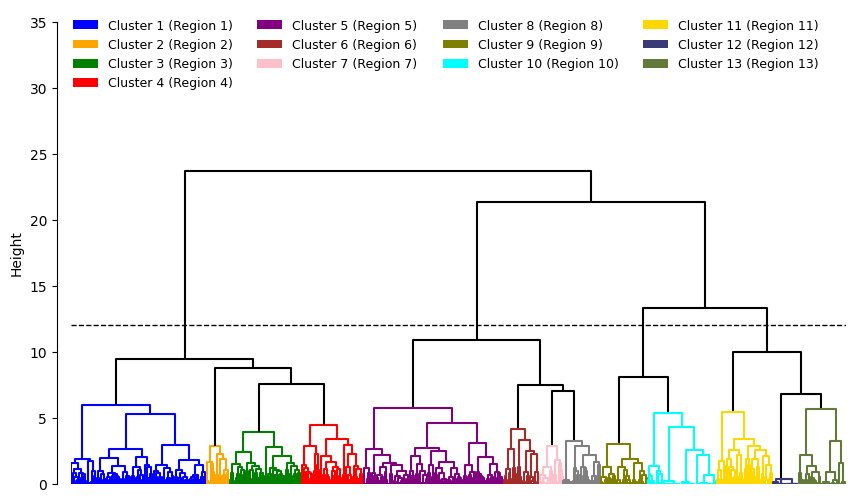

[INFO] Dendrogram saved: output\scenario=all\cell=40km\threshold=5\cluster_number\all_40km_5_dendrogram_20260110.tif


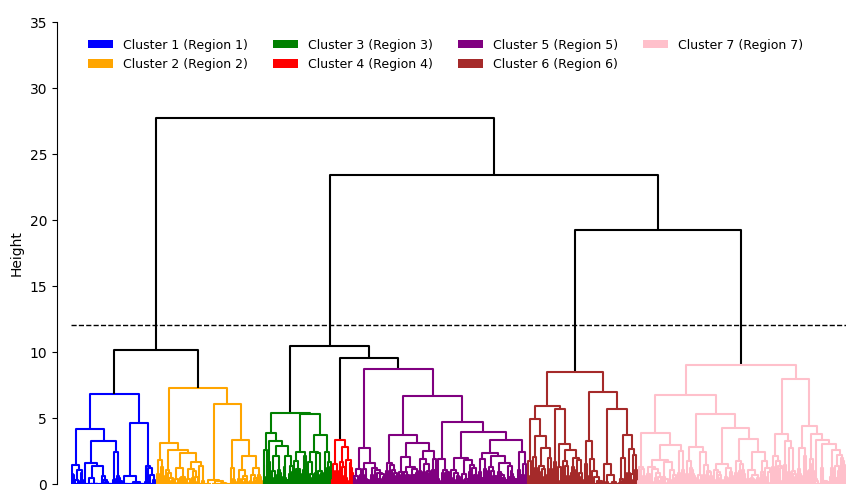

[INFO] Dendrogram saved: output\scenario=all\cell=40km\threshold=1\cluster_number\all_40km_1_dendrogram_20260110.tif


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from matplotlib.colors import to_rgb, to_hex
import matplotlib.patches as mpatches
from datetime import datetime


def adjust_alpha(color_hex, alpha):
    """将十六进制颜色和透明度合并为新的十六进制颜色"""
    rgb = to_rgb(color_hex)
    # 模拟透明度效果：混合白色背景
    blended = [1 - alpha + c * alpha for c in rgb]
    return to_hex(blended)

def fun_dendrogram(scenario, cell_size, threshold, method='ward'):
    # 1. 读取数据
    base = Path(f'output/scenario={scenario}/cell={int(cell_size/1e3)}km/threshold={threshold}')
    cluster_df = pd.read_excel(base / 'cluster_number' / f'{scenario}_{int(cell_size/1e3)}km_{threshold}_grid_cluster.xlsx')
    cluster_dict = dict(zip(cluster_df['grid_index'], cluster_df['cluster']))
    n_clusters = cluster_df['cluster'].nunique()
    clusters = sorted(cluster_df['cluster'].unique())
    
    dissim_matrix = pd.read_excel(
        base / f'{scenario}_{int(cell_size/1e3)}km_{threshold}_beta_diversity_matrix.xlsx',
        index_col=0
    )
    condensed_dist = squareform(dissim_matrix.values)
    Z = linkage(condensed_dist, method=method)
    threshold_distance = Z[-(n_clusters - 1), 2]

    # 2. 颜色定义（包含原始颜色和透明度信息）
    cluster_styles = {
        1:  {'color': 'blue', 'alpha': 1.0}, #1-2, same region
        2:  {'color': 'orange', 'alpha': 1.0}, #1-2, same region
        3:  {'color': 'green', 'alpha': 1.0}, #3-4-5, same region
        4:  {'color': 'red', 'alpha': 1.0}, #3-4-5, same region
        5:  {'color': 'purple', 'alpha': 1.0}, #3-4-5, same region
        6:  {'color': 'brown', 'alpha': 1.0}, #6-7, same region
        7:  {'color': 'pink', 'alpha': 1.0}, #6-7, same region
        8:  {'color': 'gray', 'alpha': 1.0}, #8-9-10, same region
        9:  {'color': 'olive', 'alpha': 1.0}, #8-9-10, same region
        10: {'color': 'cyan', 'alpha': 1.0}, #8-9-10, same region
        11: {'color': 'gold', 'alpha': 1.0}, #8-9-10, same region
        12: {'color': '#393B79', 'alpha': 1.0}, #8-9-10, same region
        13: {'color': '#637939', 'alpha': 1.0}, #8-9-10, same region
        14: {'color': '#8C6D31', 'alpha': 1.0}, #8-9-10, same region
        15: {'color': '#843C39', 'alpha': 1.0} #8-9-10, same region
    }
    
    # 3. 预计算带透明度的显示颜色（关键修正：使用正确的函数名）
    cluster_colors = {cl: adjust_alpha(style['color'], style['alpha']) 
                     for cl, style in cluster_styles.items()}

    # 4. link_color_func 使用预处理后的颜色
    def link_color_func(k):
        if k < len(dissim_matrix):
            return '#000000'
        
        def get_leaf_clusters(node):
            if node < len(dissim_matrix):
                grid_id = dissim_matrix.index[node]
                return {cluster_dict[grid_id]}
            left = int(Z[node - len(dissim_matrix), 0])
            right = int(Z[node - len(dissim_matrix), 1])
            return get_leaf_clusters(left) | get_leaf_clusters(right)
        
        clusters = get_leaf_clusters(k)
        return cluster_colors[list(clusters)[0]] if len(clusters) == 1 else '#000000'

    # 5. 绘制树状图
    fig, ax = plt.subplots(figsize=(10, 6))
    dendrogram(
        Z,
        ax=ax,
        no_labels=True,
        color_threshold=threshold_distance,
        above_threshold_color='black',
        link_color_func=link_color_func
    )

    # 6. 添加图例
    cluster_to_region = {
        1: 'Region 1', 
        2: 'Region 2',
        3: 'Region 3', 
        4: 'Region 4', 
        5: 'Region 5',
        6: 'Region 6',
        7: 'Region 7',
        8: 'Region 8', 
        9: 'Region 9',
        10: 'Region 10',
        11: 'Region 11',
        12: 'Region 12', 
        13: 'Region 13',
        14: 'Region 14',
        15: 'Region 15'
    }
    
    # 创建图例元素（使用原始颜色和透明度）
    handles = [
        mpatches.Patch(
            facecolor=cluster_styles[cl]['color'],
            alpha=cluster_styles[cl]['alpha'],
            label=f'Cluster {cl} ({cluster_to_region[cl]})'
        )
        for cl in clusters if cl in cluster_styles
    ]
    
    ax_legend = fig.add_axes([0.1, 0.75, 0.8, 0.15])  # 调整图例位置
    ax_legend.legend(
        handles=handles,
        loc='center',
        frameon=False,
        ncols=4,
        fontsize=9
    )
    ax_legend.set_axis_off()

    # 7. 样式调整
    ax.axhline(y=12, linestyle='--', color='black', lw=1)
    ax.set_ylabel('Height', fontsize=10)
    ax.set_ylim(0, 35)
    for side in ['top', 'right', 'bottom']:
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_position(('outward', 10))
    
    # plt.tight_layout()
    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    save_path = base / 'cluster_number' / f'{scenario}_{int(cell_size/1e3)}km_{threshold}_dendrogram_{date_str}.tif'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.show()
    print(f'[INFO] Dendrogram saved: {save_path}')

# 示例用法
fun_dendrogram(scenario='all', cell_size=40000, threshold=5)
fun_dendrogram(scenario='all', cell_size=40000, threshold=1)